<a href="https://colab.research.google.com/github/Karlis00/ai-heart-disease-classifier/blob/main/AIDI1011_AI_Project_Heart_Disease_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIDI 1011 AI Project - Heart Disease Classifier
### Team members:
#### Kam Hung Chan
#### Josiah Grimm
#### Jay Patel

# Introduction

# Problem Statement




#####Electrocardiogram (ECG) interpretation is a complex and time-consuming task that requires specialized clinical expertise. Due to a shortage of cardiology and cardiac physiology professionals in clinics, healthcare centers, and ambulance services, manually reviewing all ECG recordings for potential heart abnormalities can be challenging and prone to inconsistency. There is a growing need for an automated system that can assist clinicians and paramedics by identifying abnormal ECG patterns that may indicate heart disease, enabling faster, more consistent, and more reliable screening.




## Scope
#####The project focuses on developing an AI-based classification model using the PTB-XL dataset (Wagner et al., 2020), which contains over 20,000 clinically annotated 12-lead ECG recordings. The system is intended to serve as a decision-support tool, capable of:
* Analyzing 12-lead ECG signals to detect abnormal patterns
* Performing multiclass heart disease classification into clinically relevant categories
* Supporting pre-diagnosis or screening to prioritize ECGs for further medical review

## Exclusions / Boundaries:
* The model is not intended for real-time diagnosis or clinical use
* It will not provide treatment recommendations or replace clinician judgment
* Focus is on offline classification and educational research purposes

# Dataset Description (PTB-XL)


#####The PTB-XL dataset is a large, publicly available clinical ECG dataset collected in Germany at the Physikalisch-Technische Bundesanstalt (PTB) and the University Medical Center Mainz, and later published on PhysioNet. It contains 21,837 ten-second 12-lead ECG recordings sampled at 100 Hz and 500 Hz, with expert annotations provided as SCP codes that map to diagnostic superclasses such as MI, STTC, CD, HYP, and NORM. In addition to the ECG signals, the dataset includes patient metadata such as age and sex, making it a widely used benchmark for developing and evaluating AI models for automated ECG classification (Wagner et al., 2020).

# Literature Review


## Kam's literature Review
Śmigiel et al. (2021) investigated deep learning approaches for automatic ECG classification using the PTB-XL dataset, focusing on designing lightweight yet effective models for multi-class diagnosis. After filtering the dataset to 17,232 high-confidence labeled ECG records sampled at 100 Hz, the authors evaluated three architectures for 2-class, 5-class, and 20-class classification: a compact 1D convolutional neural network (CNN), a SincNet-based model originally designed for speech signals, and a CNN augmented with entropy-based signal features. The study emphasized computational efficiency, using small models suitable for embedded or mobile deployment, and assessed performance using accuracy, precision, recall, F1-score, and AUC.

The key finding of the study was that combining CNN features with entropy measures (e.g., Shannon, sample, permutation, spectral entropy) significantly improved classification performance across all tasks. The CNN with entropy features achieved the best results, reaching 76.5% accuracy for five diagnostic classes and 69.8% for twenty subclasses, outperforming both the basic CNN and the much larger SincNet model. The authors concluded that while simple 1D CNNs are highly effective for ECG signals, incorporating handcrafted signal complexity features can further enhance performance in multi-class ECG diagnosis using PTB-XL.

## Josiah literature review
The study by Atwa et al. (2025) developed and evaluated two deep learning models a custom convolutional neural network (CNN) with a dual-branch architecture incorporating ECG signals and demographic data (age, gender), and a modified VGG16 adapted for similar inputs—to automatically classify arrhythmias from the large PTB-XL 12-lead ECG dataset (>20 000 recordings) across binary and multiclass tasks (2, 5, 10, and 15 classes), applying advanced preprocessing, training with Adam optimization, early stopping, and evaluation on standardized train/validation/test splits; the CNN outperformed the VGG16 and recent benchmarks by achieving up to 97.78% accuracy in binary classification and around 79.7% in multiclass settings, with inclusion of demographic features improving performance, they also used explainability analyses to highlight lead specific contributions to predictions, underscoring both high classification performance and clinical interpretability of their models for ECG-based arrhythmia detection (Atwa et al., 2025).



## Jay's Literature Review

Early detection of cardiac abnormalities is essential for preventing severe cardiovascular events, yet many clinics lack the capacity for rapid ECG interpretation. Automated ECG classification systems can support clinicians by providing fast, consistent pre‑screening. The PTB‑XL dataset has become a widely adopted benchmark for developing such systems due to its size, diagnostic richness, and standardized train/test splits.

Kachuee et al. (2021) – Transferable ECG Representations Using Deep Residual CNNs Kachuee et al. investigate deep residual convolutional networks for ECG classification and evaluate their generalization on PTB‑XL. Their ResNet‑1D architecture learns robust morphological features that transfer across datasets. This work demonstrates the effectiveness of deep residual blocks for ECG modeling and motivates the use of ResNet‑style architectures as a baseline.

Strodthoff et al. (2021) – Multilabel ECG Classification with Inception‑Style CNNs Strodthoff et al. propose a multilabel deep learning framework for PTB‑XL using Inception‑style 1D CNNs, fully convolutional networks, and multi‑scale convolutional filters. Their results show that multi‑branch architectures outperform simple CNNs by capturing diverse temporal patterns in ECG signals. This motivates the inclusion of Inception‑1D and multi‑scale CNNs as baselines.

Hong et al. (2020) – Attention‑Enhanced CNNs for Arrhythmia Detection Hong et al. introduce an attention‑based CNN for arrhythmia detection using PTB‑XL. Their model incorporates temporal and lead‑wise attention mechanisms, improving interpretability and diagnostic relevance. This work provides a clinically meaningful baseline for attention‑enhanced ECG classification.

# Experimental Approaches

## Jay's model

In my part of the project, I implemented and compared three deep learning architectures on the cleaned and normalized PTB‑XL dataset: a baseline 1D Convolutional Neural Network (CNN), a ResNet‑1D model, and a Dilated Multi‑Scale CNN. The baseline 1D CNN learns local temporal and morphological features across the 12 ECG leads using stacked convolutional layers with batch normalization and dropout. The ResNet‑1D architecture extends this idea with residual connections, allowing deeper feature extraction while maintaining stable training. The Dilated Multi‑Scale CNN uses parallel dilated convolutions with different receptive fields to capture both fine‑grained waveform details and longer‑range temporal patterns. All models use sigmoid output layers for multi‑label classification over the diagnostic superclasses and are trained using the official PTB‑XL stratified folds. Their performance is compared using macro and micro F1‑scores, providing insight into the trade‑off between architectural complexity and classification performance.

## Josiah's model

### talk about your model, what model and tech you decide to use to build it.

## Kam's model

In this project, I will employ a hybrid CNN + Mamba architecture to classify 12-lead ECG signals from the PTB-XL dataset. The CNN component extracts local temporal features from each lead, such as QRS complexes and T-wave morphology, while the Mamba block captures long-range temporal dependencies across the entire signal. Raw ECGs are first normalized per lead, then fed in batches through the network. The model is trained using cross-entropy loss and optimized with AdamW, with performance evaluated on a held-out validation set. This approach combines the strength of CNNs in detecting local patterns with the efficient sequence modeling capability of Mamba, aiming to improve accuracy in multi-class cardiac abnormality detection.

# Setup Environment and Import Libraries

In [1]:
# install to setup the env if your colab notebook restarted
!pip install -U "pandas<2.2" wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 959.0 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 36.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import wfdb
import ast
import glob
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

Mounted at /content/drive


In [4]:
# Automatically find the PTB-XL folder
found = None
for root, dirs, files in os.walk("/content/drive/MyDrive/ECGDataset/", topdown=True):
    if "records100" in dirs:
        found = os.path.join(root, "records100")
        break

if found is None:
    raise Exception("PTB-XL dataset not found in Drive. Add shortcut to MyDrive.")

print("PTB-XL found at:", found)

# Base path
path = found.replace("records100", "")
print("Base path:", path)

PTB-XL found at: /content/drive/MyDrive/ECGDataset/records100
Base path: /content/drive/MyDrive/ECGDataset/


# Exploratory Data Analysis

## Kam's works

### Load data X and Y for the whole project

In [2]:
# load and convert annotation data
Y = pd.read_csv("/content/drive/MyDrive/ECGDataset/"
            "ptbxl_database.csv")
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

In [ ]:
# Google colab is too slow to load the data from drive
# loaded on PC and prepared the npy file instead
'''
# create a function to load data
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

sampling_rate=100

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)
'''

In [ ]:
# save as npy file to be read much quickly
# np.save(path + "X_ptbxl_100hz.npy", X)

In [5]:
X = np.load(path + "X_ptbxl_100hz.npy", mmap_mode='r')

In [6]:
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

In [7]:
def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)


### Perform EDA

In [ ]:
record_path = (
    path +
    "records100/00000/"
)

# for a single record
record = "00001_lr"

signal, meta = wfdb.rdsamp(record_path+record)

print(signal.shape)

In [ ]:
signal

In [ ]:
# we use the 100hz waveform files
meta['fs']

In [ ]:
# 12-lead ECG
meta['sig_name']

In [ ]:
fs = meta['fs']
time = np.arange(signal.shape[0]) / fs

plt.figure(figsize=(10,4))
plt.plot(time, signal[:, 1])  # Lead II
plt.xlabel("Time (s)")
plt.ylabel("mV")
plt.title("Lead II ECG")
plt.show()

In [ ]:
plt.figure(figsize=(12,10))
for i in range(12):
    plt.subplot(6, 2, i+1)
    plt.plot(time, signal[:, i])
    plt.title(meta['sig_name'][i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# explode the list of classes into rows
exploded = Y.explode('diagnostic_superclass')

# count occurrences
class_counts = exploded['diagnostic_superclass'].value_counts()

print(class_counts)

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')
plt.title('Number of ECG Records per Diagnostic Superclass')
plt.xlabel('Diagnostic Superclass')
plt.ylabel('Number of Records')
plt.show()

In [ ]:
# number of labels per ECG
Y['num_labels'] = Y['diagnostic_superclass'].apply(len)

label_count_distribution = Y['num_labels'].value_counts().sort_index()

print(label_count_distribution)

In [ ]:
# check if 'NORM' is in the label list
Y['has_norm'] = Y['diagnostic_superclass'].apply(lambda x: 'NORM' in x)

norm_records = Y[Y['has_norm']]

In [ ]:
# pure NORM = only 1 label and that label is NORM
pure_norm = norm_records[
    norm_records['diagnostic_superclass'].apply(lambda x: len(x) == 1)
]

# NORM + other classes
norm_with_others = norm_records[
    norm_records['diagnostic_superclass'].apply(lambda x: len(x) > 1)
]

print("Pure NORM records:", len(pure_norm))
print("NORM with other classes:", len(norm_with_others))

In [ ]:
# Count the two categories
pure_count = len(pure_norm)
mixed_count = len(norm_with_others)

# Labels and sizes for pie chart
labels = ['Pure NORM', 'NORM + Other Classes']
sizes = [pure_count, mixed_count]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',  # Show percentage
    startangle=90,
    colors=['#66c2a5','#fc8d62']  # optional nice colors
)
plt.title('Distribution of NORM ECG Records')
plt.show()

In [ ]:
from collections import Counter

other_labels = []

for labels_list in norm_with_others['diagnostic_superclass']:
    for label in labels_list:
        if label != 'NORM':
            other_labels.append(label)

counter = Counter(other_labels)

total_mixed = len(norm_with_others)

labels = list(counter.keys())
counts = list(counter.values())
percentages = [(c / total_mixed) * 100 for c in counts]

plt.figure(figsize=(7,7))
plt.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Other Diagnostic Classes Co-existing with NORM')
plt.show()

## Josiah's work

### Age Demographics and Heart Condition

In [ ]:
#Create a copy of dataset
df = Y.copy()

# Define heart condition flag
def has_condition(label_list):
    # If only label is NORM → no condition
    if len(label_list) == 1 and label_list[0] == 'NORM':
        return 0
    else:
        return 1

df['has_condition'] = df['diagnostic_superclass'].apply(has_condition)

print(df['has_condition'].value_counts())

In [ ]:
# Define age bins
bins = [0, 30, 40, 50, 60, 70, 80, 100]
labels = ['<30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print(df['age_group'].value_counts())

In [ ]:
# Combine the two informations and seperate by age groups
age_condition_counts = df.groupby(['age_group', 'has_condition']).size().unstack()

print(age_condition_counts)

In [ ]:
# Plot the data
age_condition_counts.plot(kind='bar', stacked=False, figsize=(8,6))

plt.title('Age Group vs Heart Condition')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(['No Condition (Pure NORM)', 'Has Condition'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Heart Conditions by Age

In [ ]:
# Explode multilabel column
df_exploded = df.explode('diagnostic_superclass')

age_super_counts = (
    df_exploded
    .groupby(['age_group', 'diagnostic_superclass'])
    .size()
    .unstack(fill_value=0)
)

print(age_super_counts)

In [ ]:
# Drop NORM since we already have that count and show the disease by superclass
age_super_no_norm = age_super_counts.drop(columns=['NORM'])

age_super_no_norm.plot(kind='bar', figsize=(10,6))

plt.title('Age Group vs Heart Disease Superclasses')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Superclass')
plt.tight_layout()
plt.show()

### Sex Demographic Data to Heart Conditions

In [ ]:
def has_condition(label_list):
    if len(label_list) == 1 and label_list[0] == 'NORM':
        return 'NORM'
    else:
        return 'Heart Condition'

df['condition_status'] = df['diagnostic_superclass'].apply(has_condition)

In [ ]:
# Seperate Male and Female
df['sex_label'] = df['sex'].map({0: 'Female', 1: 'Male'})

In [ ]:
# Output the results
sex_condition_counts = (
    df.groupby(['sex_label', 'condition_status'])
      .size()
      .unstack(fill_value=0)
)

print(sex_condition_counts)

In [ ]:
# Extract counts
female_norm = sex_condition_counts.loc['Female', 'NORM']
female_condition = sex_condition_counts.loc['Female', 'Heart Condition']
male_norm = sex_condition_counts.loc['Male', 'NORM']
male_condition = sex_condition_counts.loc['Male', 'Heart Condition']

# Combine into single list
sizes = [female_norm, female_condition, male_norm, male_condition]

labels = [
    'Female - NORM',
    'Female - Heart Condition',
    'Male - NORM',
    'Male - Heart Condition'
]

In [ ]:
plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sex and Heart Condition Distribution')
plt.tight_layout()
plt.show()

### Sex Analysis of Heart Condition Superclasses

In [ ]:
# Convert sex to readable labels
df['sex_label'] = df['sex'].map({0: 'Female', 1: 'Male'})

# Explode multilabel superclass column
df_exploded = df.explode('diagnostic_superclass')

In [ ]:
# Count and print superclasses by sex
superclass_sex_counts = (
    df_exploded
    .groupby(['diagnostic_superclass', 'sex_label'])
    .size()
    .unstack(fill_value=0)
)

print(superclass_sex_counts)

In [ ]:
# Plot the graph without NORM
super_no_norm = superclass_sex_counts.drop(index='NORM')

super_no_norm.plot(kind='bar')

plt.title('Heart Disease Superclasses by Sex')
plt.xlabel('Diagnostic Superclass')
plt.ylabel('Number of ECG Records')
plt.xticks(rotation=45)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

In [ ]:
# draft
'''

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

'''

# Jay's work


##Stratified Fold Distribution Check

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Count samples per fold
fold_counts = Y['strat_fold'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=fold_counts.index, y=fold_counts.values, palette="viridis")
plt.title("Distribution of Samples Across Stratified Folds")
plt.xlabel("Fold Number")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

## Recording Length Consistency Check

In [ ]:

# Compute lengths of all ECG recordings
lengths = [x.shape[0] for x in X]

plt.figure(figsize=(8,5))
sns.histplot(lengths, bins=20, kde=False, color='steelblue')
plt.title("Distribution of ECG Recording Lengths")
plt.xlabel("Number of Samples")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Lead‑to‑Lead Correlation Heatmap

In [ ]:
import numpy as np

# Compute correlation across leads using all samples
# Flatten each lead across all recordings
lead_matrix = X.reshape(-1, X.shape[2])  # shape: (N*1000, 12)

corr_matrix = np.corrcoef(lead_matrix.T)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", xticklabels=meta['sig_name'], yticklabels=meta['sig_name'])
plt.title("Correlation Between ECG Leads")
plt.tight_layout()
plt.show()

##Frequency Spectrum (FFT) Comparison

In [ ]:

from scipy.fft import rfft, rfftfreq

fs = 100  # sampling rate
sample = X[0,:,1]  # Lead II example

fft_vals = np.abs(rfft(sample))
freqs = rfftfreq(len(sample), 1/fs)

plt.figure(figsize=(8,5))
plt.plot(freqs, fft_vals)
plt.title("Frequency Spectrum of ECG (Lead II)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()


## ECG Beat Template (Average Waveform)


classes = ['NORM', 'MI', 'STTC']
plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    idx = Y[Y['diagnostic_superclass'].apply(lambda x: cls in x)].index[:200]
    avg_wave = X[idx].mean(axis=0)[:,1]  # Lead II

    plt.plot(avg_wave, label=cls)

plt.title("Average ECG Waveform (Lead II) for Selected Classes")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# Data Cleaning

In [8]:
Y_superclass = Y[Y['diagnostic_superclass'].apply(lambda x: len(x) > 0)]
print('Total Record', len(Y))
print('Records classified into superclasses: ', len(Y_superclass))
print('Records without superclasses: ', len(Y) - len(Y_superclass))

Total Record 21799
Records classified into superclasses:  21388
Records without superclasses:  411


In [9]:
diagnostic_codes = agg_df[agg_df['diagnostic_class'].notna()].index

def has_low_conf_diag(scp_dict):
    for code, conf in scp_dict.items():
        if code in diagnostic_codes and conf < 100:
            return True
    return False

low_conf_records = Y[Y['scp_codes'].apply(has_low_conf_diag)]
print(len(low_conf_records))

7021


In [10]:
# Remove records with low confidence (7021 records)
def is_full_confidence_diag(scp_dict):
    for code, conf in scp_dict.items():
        if code in diagnostic_codes and conf < 100:
            return False
    return True

Y_clean = Y[Y['scp_codes'].apply(is_full_confidence_diag)]

In [11]:
# Remove records without superclasses (411 records)
Y_clean = Y_clean[Y_clean['diagnostic_superclass'].apply(lambda x: len(x) > 0)]

In [12]:
print("Original:", len(Y))
print("After 100% confidence filter:", len(Y_clean))

Original: 21799
After 100% confidence filter: 14367


In [13]:
# Convert pandas index to numpy integer positions
keep_positions = Y_clean.index.to_numpy()

# Filter X using positions
X_clean = X[keep_positions]

print(X_clean.shape)
print(len(Y_clean))

(14367, 1000, 12)
14367


# Normalization

In [ ]:
'''
# Run z-score normaliztion for first time and save as .npy file for reuse

from tqdm import tqdm
import numpy as np

def zscore_per_record(X):
    X_norm = np.zeros_like(X, dtype=np.float32)

    for i in tqdm(range(X.shape[0]), desc="Z-score Normalizing ECG"):
        for lead in range(X.shape[1]):   # 12 leads
            signal = X[i, lead]
            mean = signal.mean()
            std = signal.std()

            if std != 0:
                X_norm[i, lead] = (signal - mean) / std
            else:
                X_norm[i, lead] = signal

    return X_norm

X_clean_norm = zscore_per_record(X_clean)

# save as npy file to be read much quickly
np.save(path + "X_ptbxl_clean_norm.npy", X_clean_norm)
'''

In [14]:
X_clean_norm = np.load(path + "X_ptbxl_clean_norm.npy", mmap_mode='r')

In [15]:
X_clean_norm.shape

(14367, 1000, 12)

In [ ]:
# How many samples you want
n_samples = 2000

# Total available records
total = X_clean_norm.shape[0]

# Reproducibility
np.random.seed(42)

# Randomly choose indices
selected_idx = np.random.choice(total, size=n_samples, replace=False)

# Subset X and Y
X_sub = X_clean_norm[selected_idx]
Y_sub = Y_clean.iloc[selected_idx].reset_index(drop=True)

print(X_sub.shape)
print(len(Y_sub))

In [16]:
import numpy as np

# Load X
X_clean_norm = np.load(path + "X_ptbxl_clean_norm.npy", mmap_mode='r')

# Reset index of Y to match X_clean_norm
Y_clean_reset = Y_clean.reset_index(drop=True)

print("Original dataset size:", len(Y_clean_reset))

# ---- Step 1: Find NORM samples without HYP ----
norm_no_hyp_indices = Y_clean_reset[
    Y_clean_reset['scp_codes'].apply(lambda x: 'NORM' in x and 'HYP' not in x)
].index.to_numpy()  # now safe 0…N-1 positions

print("NORM without HYP count:", len(norm_no_hyp_indices))

# ---- Step 2: Keep half ----
np.random.seed(42)
num_keep = len(norm_no_hyp_indices) // 2
norm_keep_indices = np.random.choice(norm_no_hyp_indices, size=num_keep, replace=False)

# ---- Step 3: Keep all other samples ----
all_indices = np.arange(len(Y_clean_reset))
other_indices = np.setdiff1d(all_indices, norm_no_hyp_indices)

# ---- Step 4: Combine ----
final_indices = np.concatenate([norm_keep_indices, other_indices])
np.random.shuffle(final_indices)

# ---- Step 5: Subset the datasets ----
X_reduced = X_clean_norm[final_indices]         # NumPy array
Y_reduced = Y_clean_reset.iloc[final_indices]   # DataFrame

print("New dataset size:", len(Y_reduced))

Original dataset size: 14367
NORM without HYP count: 7144
New dataset size: 10795


# Split Data for Training and Testing

In [ ]:
# small size of data for initiate model building
Y = Y_sub
X = X_sub

In [ ]:
# down size NORM data for less data imbalance

In [17]:
Y = Y_reduced
X = X_reduced

In [ ]:
# full size of data for model building
Y = Y_clean
X = X_clean_norm

In [ ]:
X.shape

In [18]:
test_fold = 10
val_fold  = 9

train_mask = (Y.strat_fold != test_fold) & (Y.strat_fold != val_fold)
val_mask   = (Y.strat_fold == val_fold)
test_mask  = (Y.strat_fold == test_fold)

X_train = X[np.where(train_mask)]
X_val   = X[np.where(val_mask)]
X_test  = X[np.where(test_mask)]

y_train = Y[train_mask].diagnostic_superclass
y_val   = Y[val_mask].diagnostic_superclass
y_test  = Y[test_mask].diagnostic_superclass

# Convert labels to multi-hot vectors
classes = ['NORM','MI','STTC','CD','HYP']

def encode(labels):
    out = np.zeros(len(classes))
    for l in labels:
        out[classes.index(l)] = 1
    return out

y_train = np.array([encode(l) for l in y_train])
y_val = np.array([encode(l) for l in y_val])
y_test  = np.array([encode(l) for l in y_test])

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (8666, 1000, 12) (8666, 5)
Val: (1082, 1000, 12) (1082, 5)
Test: (1047, 1000, 12) (1047, 5)


# Model Building

## Jay's Model(s)

### Baseline 1D CNN

In [19]:

import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def build_baseline_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 7, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

### Transfer‑ResNet‑1D

In [20]:
def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    x = layers.Conv1D(filters, kernel_size, strides=stride,
                      padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(filters, kernel_size, strides=1,
                      padding='same', activation=None)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv1D(filters, 1, strides=stride,
                                 padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_resnet1d(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 7, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = residual_block(x, 32)
    x = residual_block(x, 32)

    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

###Dilated Multi‑Scale CNN

In [21]:

def build_dilated_multiscale_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    d1 = layers.Conv1D(64, 3, padding='same', dilation_rate=1, activation='relu')(x)
    d2 = layers.Conv1D(64, 3, padding='same', dilation_rate=2, activation='relu')(x)
    d3 = layers.Conv1D(64, 3, padding='same', dilation_rate=4, activation='relu')(x)

    x = layers.Concatenate()([d1, d2, d3])
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    d4 = layers.Conv1D(128, 3, padding='same', dilation_rate=1, activation='relu')(x)
    d5 = layers.Conv1D(128, 3, padding='same', dilation_rate=2, activation='relu')(x)
    d6 = layers.Conv1D(128, 3, padding='same', dilation_rate=4, activation='relu')(x)

    x = layers.Concatenate()([d4, d5, d6])
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [22]:
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

classes = ['NORM','MI','STTC','CD','HYP']
mlb = MultiLabelBinarizer(classes=classes)

# y as multi-hot matrix
y_all = mlb.fit_transform(Y['diagnostic_superclass'])

# stratified split using provided folds
test_fold = 10

train_idx = np.where(Y['strat_fold'] != test_fold)[0]
test_idx  = np.where(Y['strat_fold'] == test_fold)[0]

X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y_all[train_idx]
y_test  = y_all[test_idx]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(9748, 1000, 12) (1047, 1000, 12) (9748, 5) (1047, 5)


In [23]:
input_shape = (X_train.shape[1], X_train.shape[2])  # (1000, 12)
num_classes = len(classes)

baseline = build_baseline_cnn(input_shape, num_classes)
resnet   = build_resnet1d(input_shape, num_classes)
dilated  = build_dilated_multiscale_cnn(input_shape, num_classes)


### Train all three models

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def train_model(model, name):
    ckpt_path = f"{name}_best.h5"
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True)
    ]
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )
    return history

hist_baseline = train_model(baseline, "baseline")
hist_resnet   = train_model(resnet, "resnet")
hist_dilated  = train_model(dilated, "dilated")



Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3776 - loss: 0.5305

244/244 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.3778 - loss: 0.5304 - val_accuracy: 0.5190 - val_loss: 0.4363
Epoch 2/10
241/244 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5232 - loss: 0.4384

244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5236 - loss: 0.4382 - val_accuracy: 0.5723 - val_loss: 0.4000
Epoch 3/10
238/244 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5913 - loss: 0.4037

244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5917 - loss: 0.4035 - val_accuracy: 0.6144 - val_loss: 0.3689
Epoch 4/10
239/244 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6458 - loss: 0.3765

244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6461 - loss: 0.3762 - val_accuracy: 0.6677 - val_loss: 0.3468
Epoch 5/10
242/244 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6740 - loss: 0.3530

...

244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.6945 - loss: 0.3412 - val_accuracy: 0.7005 - val_loss: 0.3282
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7181 - loss: 0.3195 - val_accuracy: 0.7041 - val_loss: 0.3308
Epoch 5/10
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7316 - loss: 0.3051

244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7317 - loss: 0.3051 - val_accuracy: 0.7456 - val_loss: 0.3020
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7442 - loss: 0.2881

244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7442 - loss: 0.2881 - val_accuracy: 0.7487 - val_loss: 0.2893
Epoch 7/10
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7493 - loss: 0.2814

244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7493 - loss: 0.2814 - val_accuracy: 0.7323 - val_loss: 0.2849
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7668 - loss: 0.2767 - val_accuracy: 0.7338 - val_loss: 0.2898
Epoch 9/10
242/244 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7522 - loss: 0.2799

244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7523 - loss: 0.2798 - val_accuracy: 0.7318 - val_loss: 0.2794
Epoch 10/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7691 - loss: 0.2635 - val_accuracy: 0.7262 - val_loss: 0.2865


In [25]:
# === HYP Evaluation for All Models ===

classes = ['NORM','MI','STTC','CD','HYP']
hyp_index = classes.index('HYP')

models_to_check = {
    "Baseline CNN": baseline,
    "ResNet‑1D": resnet,
    "Dilated Multi‑Scale CNN": dilated
}

for name, model in models_to_check.items():
    print(f"\n=== {name} ===")

    # Predictions
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    true_hyp = y_test[:, hyp_index].sum()
    pred_hyp = y_pred[:, hyp_index].sum()

    print("True HYP positives:", true_hyp)
    print("Predicted HYP positives:", pred_hyp)





=== Baseline CNN ===
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
True HYP positives: 103
Predicted HYP positives: 7

=== ResNet‑1D ===
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step
True HYP positives: 103
Predicted HYP positives: 40

=== Dilated Multi‑Scale CNN ===
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
True HYP positives: 103
Predicted HYP positives: 22


In [ ]:
histories = {}

histories["Baseline 1D CNN"] = baseline.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

histories["ResNet-1D"] = resnet.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

histories["Dilated Multi-Scale CNN"] = dilated.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)


## Josiah's Model

In [27]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, classification_report


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use tensors on the dataset
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.float32)

        # If data is (1000, 12), transpose to (12, 1000)
        if x.shape[0] == 1000 and x.shape[1] == 12:
            x = x.transpose(0, 1)

        return x, y


train_cnn_dataset = ECGDataset(X_train, y_train)
val_cnn_dataset   = ECGDataset(X_val, y_val)
test_cnn_dataset  = ECGDataset(X_test, y_test)

train_cnn_loader = DataLoader(train_cnn_dataset, batch_size=64, shuffle=True)
val_cnn_loader   = DataLoader(val_cnn_dataset, batch_size=64)
test_cnn_loader  = DataLoader(test_cnn_dataset, batch_size=64)

print("Train samples:", len(train_cnn_loader.dataset))
print("Val samples:", len(val_cnn_loader.dataset))
print("Test samples:", len(test_cnn_loader.dataset))

Train samples: 9748
Val samples: 1082
Test samples: 1047


In [28]:
import torch.nn as nn
import torch.nn.functional as F

# Create the model
class ECG_CNN(nn.Module):
    def __init__(self, num_classes=5):
        super(ECG_CNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv1d(12, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.block4 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.global_pool(x)  # (batch, 256, 1)
        x = x.squeeze(-1)        # (batch, 256)

        return self.classifier(x)

In [75]:
# Create and initialize model
model = ECG_CNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [30]:
# Performs training per epoch
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [31]:
# Evaluation Function
def evaluate_with_metrics(model, loader):
    model.eval()

    total_loss = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            probs = torch.sigmoid(outputs)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    # Binary predictions
    preds = (all_probs > 0.5).astype(int)

    # AUROC
    macro_auroc = roc_auc_score(all_labels, all_probs, average="macro")
    per_class_auroc = roc_auc_score(all_labels, all_probs, average=None)

    # F1
    macro_f1 = f1_score(all_labels, preds, average="macro")
    per_class_f1 = f1_score(all_labels, preds, average=None)

    return {
        "loss": total_loss / len(loader),
        "macro_auroc": macro_auroc,
        "per_class_auroc": per_class_auroc,
        "macro_f1": macro_f1,
        "per_class_f1": per_class_f1
    }


In [32]:
# Kam's evaluation function for Josiah's Baseline Model

def compute_per_class_metrics_cnn(model, loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = torch.sigmoid(model(xb))  # probabilities
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    all_preds = np.vstack(all_preds)   # (num_samples, n_classes)
    all_labels = np.vstack(all_labels)

    n_classes = all_labels.shape[1]

    f1_per_class = []
    precision_per_class = []
    recall_per_class = []
    auroc_per_class = []

    for i in range(n_classes):

        # Handle missing classes
        if all_labels[:, i].sum() == 0:
            f1_per_class.append(np.nan)
            precision_per_class.append(np.nan)
            recall_per_class.append(np.nan)
            auroc_per_class.append(np.nan)

        else:
            preds_binary = all_preds[:, i] > threshold

            f1_per_class.append(
                f1_score(all_labels[:, i], preds_binary)
            )

            precision_per_class.append(
                precision_score(all_labels[:, i], preds_binary)
            )

            recall_per_class.append(
                recall_score(all_labels[:, i], preds_binary)
            )

            auroc_per_class.append(
                roc_auc_score(all_labels[:, i], all_preds[:, i])
            )

    # Macro metrics
    macro_f1 = np.nanmean(f1_per_class)
    macro_precision = np.nanmean(precision_per_class)
    macro_recall = np.nanmean(recall_per_class)
    macro_auroc = np.nanmean(auroc_per_class)

    return {
        "f1_per_class": f1_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "auroc_per_class": auroc_per_class,

        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_auroc": macro_auroc
    }

## Josiah's Evaluation

In [33]:
# Sequence to run the model
history = {
    "train_loss": [],
    "val_loss": [],
    "macro_auroc": [],
    "macro_f1": [],
    "per_class_auroc": []
}

epochs = 20

for epoch in range(epochs):
    train_loss = train_epoch(model, train_cnn_loader)

    val_metrics = evaluate_with_metrics(model, val_cnn_loader)

    # Save metrics to history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["macro_auroc"].append(val_metrics["macro_auroc"])
    history["macro_f1"].append(val_metrics["macro_f1"])
    history["per_class_auroc"].append(val_metrics["per_class_auroc"])

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f}")
    print(f"Macro AUROC: {val_metrics['macro_auroc']:.4f}")
    print(f"Macro F1: {val_metrics['macro_f1']:.4f}")

    print("\nPer-class AUROC:")
    for i, cls in enumerate(classes):
        print(f"{cls}: {val_metrics['per_class_auroc'][i]:.4f}")


Epoch 1/20
Train Loss: 0.4046
Val Loss: 0.4164
Macro AUROC: 0.8767
Macro F1: 0.4175

Per-class AUROC:
NORM: 0.9507
MI: 0.9059
STTC: 0.8743
CD: 0.8683
HYP: 0.7844

Epoch 2/20
Train Loss: 0.3292
Val Loss: 0.3274
Macro AUROC: 0.8964
Macro F1: 0.5757

Per-class AUROC:
NORM: 0.9614
MI: 0.9121
STTC: 0.9219
CD: 0.8995
HYP: 0.7870

Epoch 3/20
Train Loss: 0.3056
Val Loss: 0.2797
Macro AUROC: 0.9077
Macro F1: 0.6348

Per-class AUROC:
NORM: 0.9711
MI: 0.9375
STTC: 0.9313
CD: 0.9043
HYP: 0.7941

Epoch 4/20
Train Loss: 0.2914
Val Loss: 0.3933
Macro AUROC: 0.9038
Macro F1: 0.5791

Per-class AUROC:
NORM: 0.9674
MI: 0.9438
STTC: 0.9028
CD: 0.8948
HYP: 0.8101

Epoch 5/20
Train Loss: 0.2796
Val Loss: 0.2797
Macro AUROC: 0.9172
Macro F1: 0.6676

Per-class AUROC:
NORM: 0.9736
MI: 0.9484
STTC: 0.9292
CD: 0.9116
HYP: 0.8230

Epoch 6/20
Train Loss: 0.2748
Val Loss: 0.2721
Macro AUROC: 0.9177
Macro F1: 0.6327

Per-class AUROC:
NORM: 0.9733
MI: 0.9501
STTC: 0.9232
CD: 0.9276
HYP: 0.8141

Epoch 7/20
Train Loss

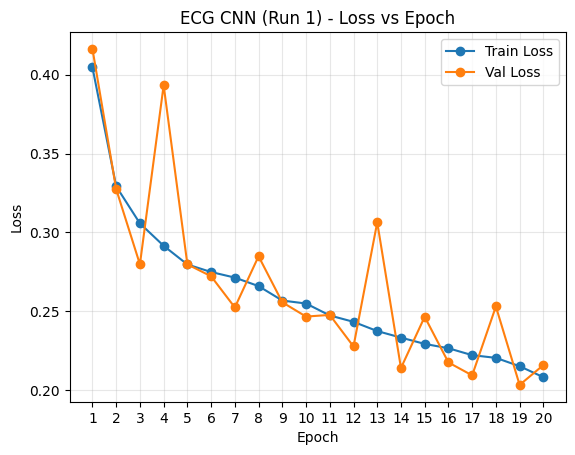

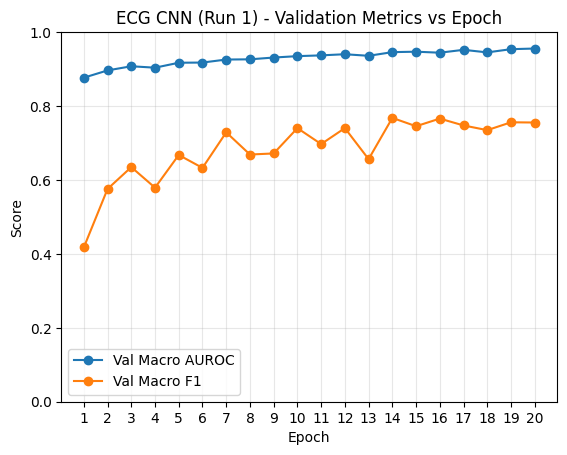

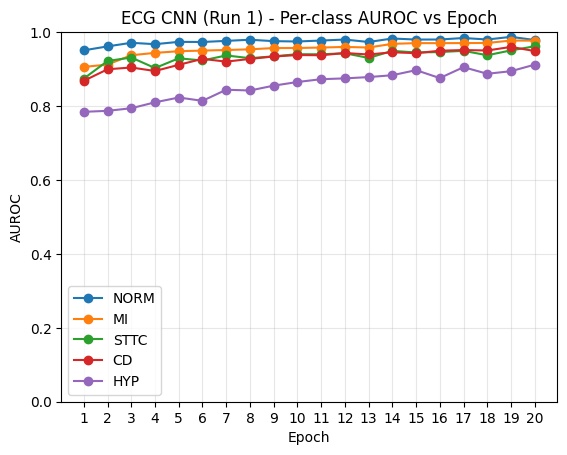

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def plot_history(history, classes, title_prefix="Model"):
    # history keys expected:
    # train_loss, val_loss, macro_auroc, macro_f1, per_class_auroc (list of length-5 arrays)
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    per_class = np.array(history["per_class_auroc"])  # (epochs, 5)

    # Loss
    plt.figure()
    plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss vs Epoch")
    plt.xticks(epochs)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Macro AUROC and Macro F1
    plt.figure()
    plt.plot(epochs, history["macro_auroc"], marker="o", label="Val Macro AUROC")
    plt.plot(epochs, history["macro_f1"], marker="o", label="Val Macro F1")
    plt.xlabel("Epoch"); plt.ylabel("Score")
    plt.title(f"{title_prefix} - Validation Metrics vs Epoch")
    plt.xticks(epochs)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Per-class AUROC
    plt.figure()
    for i, cls in enumerate(classes):
        plt.plot(epochs, per_class[:, i], marker="o", label=cls)
    plt.xlabel("Epoch"); plt.ylabel("AUROC")
    plt.title(f"{title_prefix} - Per-class AUROC vs Epoch")
    plt.xticks(epochs)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

classes = ['NORM','MI','STTC','CD','HYP']
plot_history(history, classes, title_prefix="ECG CNN (Run 1)")

## Kam's Model

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

# create dataset class


class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].permute(0, 1)   # (1000,12) → (12,1000)
        return x, self.y[idx]

In [36]:
# create CNN + MAMBA BLOCK

class MambaLayer(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.linear = nn.Linear(d_model, d_model)
        self.activation = nn.GELU()

    def forward(self, x):
        # x: (batch, channels, seq_len)
        x = x.permute(0,2,1)
        out = self.activation(self.linear(x))
        out = out.permute(0,2,1)
        return out

class CNN_MAMBA(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.conv1 = nn.Conv1d(12, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)
        self.pool  = nn.MaxPool1d(4)

        self.mamba = MambaLayer(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)

        self.fc1   = nn.Linear(64*62, 128)
        self.out   = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.mamba(x)            # Mamba sequence block
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.out(x)

class CNN_MAMBA_v2(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()

        # ----- CNN Block 1 -----
        self.conv1 = nn.Conv1d(12, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)

        # ----- CNN Block 2 -----
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)

        # ----- Mamba Block -----
        self.mamba = MambaLayer(64)

        # ----- CNN Block 3 -----
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn3   = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(2)

        # ----- Classifier -----
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(128, 128)
        self.out = nn.Linear(128, n_classes)

    def forward(self, x):

        # CNN 1
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))

        # CNN 2
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))

        # Mamba (sequence modeling)
        x = self.mamba(x)

        # CNN 3
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))

        # Global pooling instead of flattening huge vector
        x = self.global_pool(x).squeeze(-1)

        x = torch.relu(self.fc1(x))
        return self.out(x)

class CNN_MAMBA_v3(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()

        # ----- CNN Block 1 -----
        self.conv1 = nn.Conv1d(12, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)

        # ----- CNN Block 2 -----
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)

        # ----- CNN Block 3 -----
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn3   = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(2)

        # ----- Mamba Block -----
        self.mamba = MambaLayer(128)

        # ----- Classifier -----
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(128, 128)
        self.out = nn.Linear(128, n_classes)

    def forward(self, x):

        # CNN 1
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))

        # CNN 2
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))

        # CNN 3
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))

        # Mamba (sequence modeling on rich features)
        x = self.mamba(x)

        # Global pooling
        x = self.global_pool(x).squeeze(-1)

        x = torch.relu(self.fc1(x))
        return self.out(x)

In [38]:
model_mamba = CNN_MAMBA_v3(n_classes=5)
print(model_mamba.out)

Linear(in_features=128, out_features=5, bias=True)


In [39]:
# Training Piepline

def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    model = model.to(device)
    for xb, yb in loader:
        xb = xb.permute(0,2,1).to(device)  # <-- permute here
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)



In [40]:
# evaluation function

def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.permute(0,2,1).to(device)  # <-- permute here too
            yb = yb.to(device)

            outputs = model(xb)
            preds = torch.sigmoid(outputs) > 0.5

            correct += (preds == yb.bool()).sum().item()
            total += yb.numel()
    return correct / total

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.permute(0,2,1).to(device)
            yb = yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            total_loss += loss.item()
    return total_loss / len(loader)

def compute_per_class_metrics(model, loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.permute(0,2,1).to(device)   # (batch, channels, seq_len)
            yb = yb.to(device)

            outputs = torch.sigmoid(model(xb))  # probabilities
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    all_preds = np.vstack(all_preds)   # (num_samples, n_classes)
    all_labels = np.vstack(all_labels)

    n_classes = all_labels.shape[1]

    f1_per_class = []
    precision_per_class = []
    recall_per_class = []
    auroc_per_class = []

    for i in range(n_classes):

        # Handle missing classes
        if all_labels[:, i].sum() == 0:
            f1_per_class.append(np.nan)
            precision_per_class.append(np.nan)
            recall_per_class.append(np.nan)
            auroc_per_class.append(np.nan)

        else:
            preds_binary = all_preds[:, i] > threshold

            f1_per_class.append(
                f1_score(all_labels[:, i], preds_binary)
            )

            precision_per_class.append(
                precision_score(all_labels[:, i], preds_binary)
            )

            recall_per_class.append(
                recall_score(all_labels[:, i], preds_binary)
            )

            auroc_per_class.append(
                roc_auc_score(all_labels[:, i], all_preds[:, i])
            )

    # Macro metrics
    macro_f1 = np.nanmean(f1_per_class)
    macro_precision = np.nanmean(precision_per_class)
    macro_recall = np.nanmean(recall_per_class)
    macro_auroc = np.nanmean(auroc_per_class)

    return {
        "f1_per_class": f1_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "auroc_per_class": auroc_per_class,

        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_auroc": macro_auroc
    }

In [41]:
# load data

train_ds = ECGDataset(X_train, y_train)
val_ds   = ECGDataset(X_val, y_val)
test_ds  = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)


In [44]:
# RUN

model_mamba = CNN_MAMBA_v3(n_classes=5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
opt   = torch.optim.AdamW(model_mamba.parameters(), lr=1e-4)

# for loss function
y_train_np = np.array(y_train)
num_samples = y_train_np.shape[0]
# positives per class
num_positive = y_train_np.sum(axis=0)   # shape: (5,)
num_negative = num_samples - num_positive  # shape: (5,)
pos_weight = num_negative / (num_positive + 1e-6)
# convert to tensor and move to device
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)
# create loss
crit = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


train_losses = []
val_losses   = []
val_accs     = []
val_metrics_history = []

for epoch in range(15):
    train_loss = train(model_mamba, train_loader, opt, crit, device)
    val_loss   = evaluate_loss(model_mamba, val_loader, crit, device)  # separate function
    acc  = evaluate(model_mamba, test_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(acc)
    metrics = compute_per_class_metrics(model_mamba, val_loader, device)
    val_metrics_history.append(metrics)

    print(f"Epoch {epoch+1} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | acc={acc:.4f}")


Epoch 1 | train_loss=0.9206 | val_loss=0.8025 | acc=0.7093
Epoch 2 | train_loss=0.7890 | val_loss=0.7327 | acc=0.7473
Epoch 3 | train_loss=0.7375 | val_loss=0.6932 | acc=0.7521
Epoch 4 | train_loss=0.7011 | val_loss=0.6523 | acc=0.7803
Epoch 5 | train_loss=0.6723 | val_loss=0.6365 | acc=0.7798
Epoch 6 | train_loss=0.6497 | val_loss=0.6203 | acc=0.8084
Epoch 7 | train_loss=0.6351 | val_loss=0.6171 | acc=0.8115
Epoch 8 | train_loss=0.6139 | val_loss=0.5829 | acc=0.8118
Epoch 9 | train_loss=0.5969 | val_loss=0.6003 | acc=0.8220
Epoch 10 | train_loss=0.5894 | val_loss=0.5710 | acc=0.8180
Epoch 11 | train_loss=0.5738 | val_loss=0.5701 | acc=0.8223
Epoch 12 | train_loss=0.5614 | val_loss=0.5786 | acc=0.8382
Epoch 13 | train_loss=0.5519 | val_loss=0.5428 | acc=0.8246
Epoch 14 | train_loss=0.5479 | val_loss=0.5346 | acc=0.8252
Epoch 15 | train_loss=0.5366 | val_loss=0.5319 | acc=0.8346


# Model Evaluation

## Jay's Evaluation

In [45]:
# === Model Evaluation (All Three Models) ===

from sklearn.metrics import f1_score

def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_bin = (y_pred > 0.5).astype(int)

    macro = f1_score(y_test, y_bin, average='macro')
    micro = f1_score(y_test, y_bin, average='micro')

    print(f"{name}: Macro F1 = {macro:.3f}, Micro F1 = {micro:.3f}")
    return macro, micro

# Evaluate all models
base_macro, base_micro = evaluate(baseline, "Baseline 1D CNN")
res_macro,  res_micro  = evaluate(resnet,   "ResNet-1D")
dil_macro,  dil_micro  = evaluate(dilated,  "Dilated Multi-Scale CNN")




33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Baseline 1D CNN: Macro F1 = 0.604, Micro F1 = 0.700
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
ResNet-1D: Macro F1 = 0.656, Micro F1 = 0.711
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Dilated Multi-Scale CNN: Macro F1 = 0.665, Micro F1 = 0.744


In [46]:
# === Model Comparison Table ===

comparison = pd.DataFrame({
    "Model": ["Baseline 1D CNN", "ResNet-1D", "Dilated Multi-Scale CNN"],
    "Macro F1": [base_macro, res_macro, dil_macro],
    "Micro F1": [base_micro, res_micro, dil_micro]
})

comparison


,Model,Macro F1,Micro F1
0,Baseline 1D CNN,0.603541,0.699520
1,ResNet-1D,0.655893,0.710526
2,Dilated Multi-Scale CNN,0.664605,0.743981


In [ ]:
# === Training vs Validation Loss for All Models ===

plt.figure(figsize=(12,6))

# Baseline
plt.plot(histories["Baseline 1D CNN"].history['loss'],     label='Baseline - Train Loss')
plt.plot(histories["Baseline 1D CNN"].history['val_loss'], label='Baseline - Val Loss')

# ResNet
plt.plot(histories["ResNet-1D"].history['loss'],     label='ResNet - Train Loss')
plt.plot(histories["ResNet-1D"].history['val_loss'], label='ResNet - Val Loss')

# Dilated Multi-Scale CNN
plt.plot(histories["Dilated Multi-Scale CNN"].history['loss'],     label='Dilated - Train Loss')
plt.plot(histories["Dilated Multi-Scale CNN"].history['val_loss'], label='Dilated - Val Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [47]:
from sklearn.metrics import classification_report
import pandas as pd

# Threshold-based multi-label predictions
def evaluate_multilabel(models, X_test, y_test, class_names):
    results = {}

    for name, model in models.items():
        print(f"\nEvaluating {name}...")

        # Predict probabilities
        y_pred_prob = model.predict(X_test)

        # Convert sigmoid outputs to binary predictions
        y_pred = (y_pred_prob > 0.5).astype(int)

        # Classification report
        report = classification_report(
            y_test,
            y_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        df = pd.DataFrame(report).transpose()
        results[name] = df
        print(df)

    return results

# Run evaluation
class_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

models = {
    "Baseline 1D CNN": baseline,
    "ResNet-1D": resnet,
    "Dilated Multi-Scale CNN": dilated
}

results = evaluate_multilabel(models, X_test, y_test, class_names)




Evaluating Baseline 1D CNN...
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score  support
NORM           0.762533  0.850000  0.803894    340.0
MI             0.809524  0.666667  0.731183    204.0
STTC           0.873303  0.553009  0.677193    349.0
CD             0.863415  0.558360  0.678161    317.0
HYP            1.000000  0.067961  0.127273    103.0
micro avg      0.818367  0.610815  0.699520   1313.0
macro avg      0.861755  0.539199  0.603541   1313.0
weighted avg   0.842261  0.610815  0.675485   1313.0
samples avg    0.694206  0.649156  0.657816   1313.0

Evaluating ResNet-1D...
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score  support
NORM           0.864583  0.732353  0.792994    340.0
MI             0.869565  0.490196  0.626959    204.0
STTC           0.739837  0.782235  0.760446    349.0
CD             0.690554  0.668770  0.679487    317.0
HYP            0.750000  0.291262  0.419580    103.0
micro avg      0.7

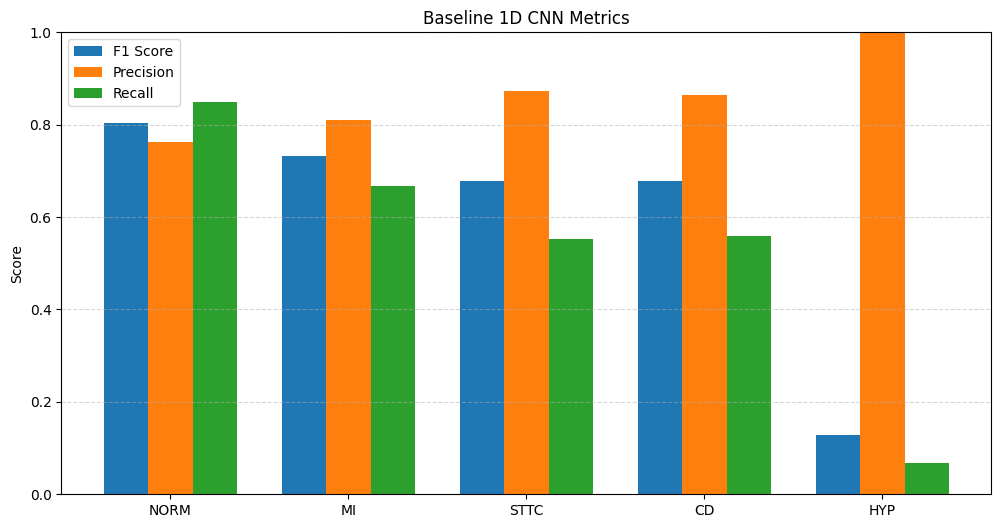

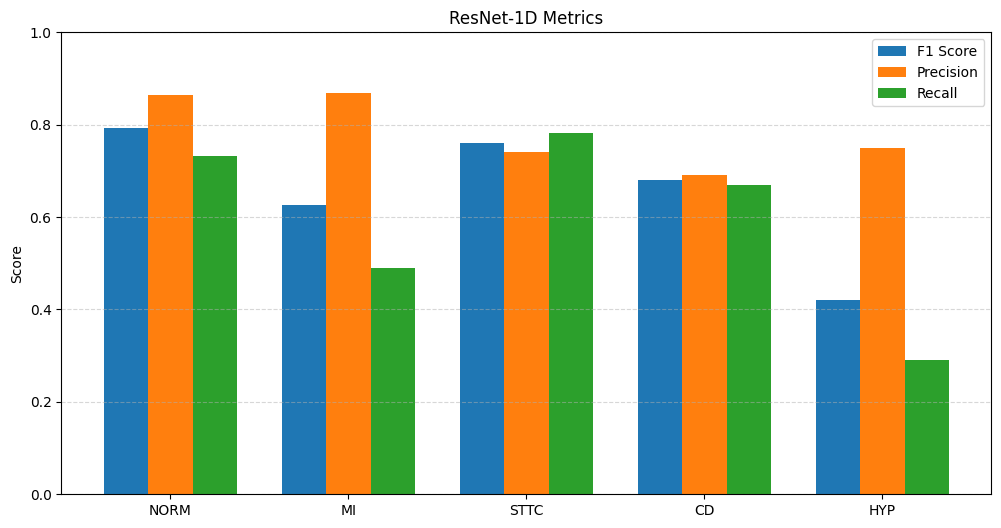

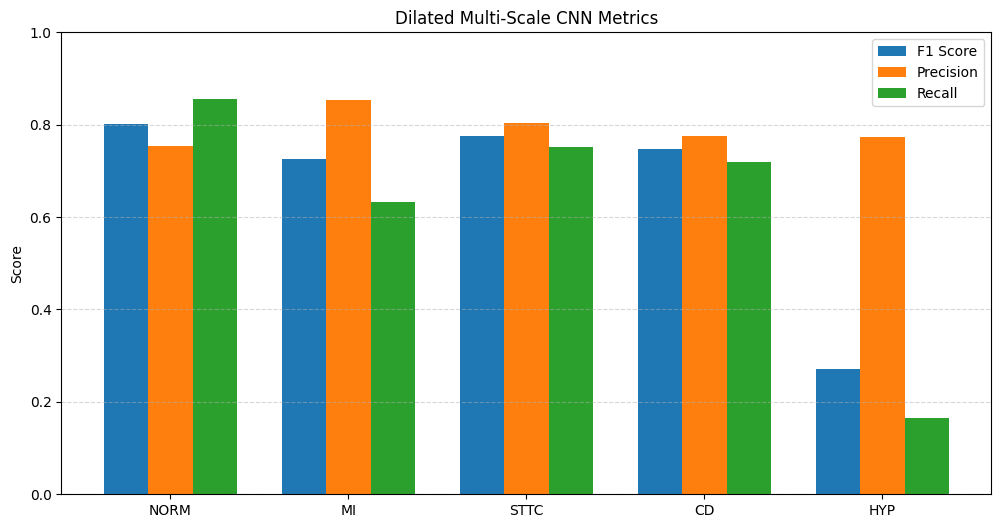

In [48]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_for_model(model_name, results, class_names):
    df = results[model_name]

    # Extract metrics
    f1 = df.loc[class_names, "f1-score"].values
    precision = df.loc[class_names, "precision"].values
    recall = df.loc[class_names, "recall"].values

    x = np.arange(len(class_names))
    width = 0.25

    plt.figure(figsize=(12,6))
    plt.bar(x - width, f1, width, label='F1 Score')
    plt.bar(x, precision, width, label='Precision')
    plt.bar(x + width, recall, width, label='Recall')

    plt.xticks(x, class_names)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(f"{model_name} Metrics")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# Generate plots for all three models
class_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

plot_metrics_for_model("Baseline 1D CNN", results, class_names)
plot_metrics_for_model("ResNet-1D", results, class_names)
plot_metrics_for_model("Dilated Multi-Scale CNN", results, class_names)


## Kam's Evaluation

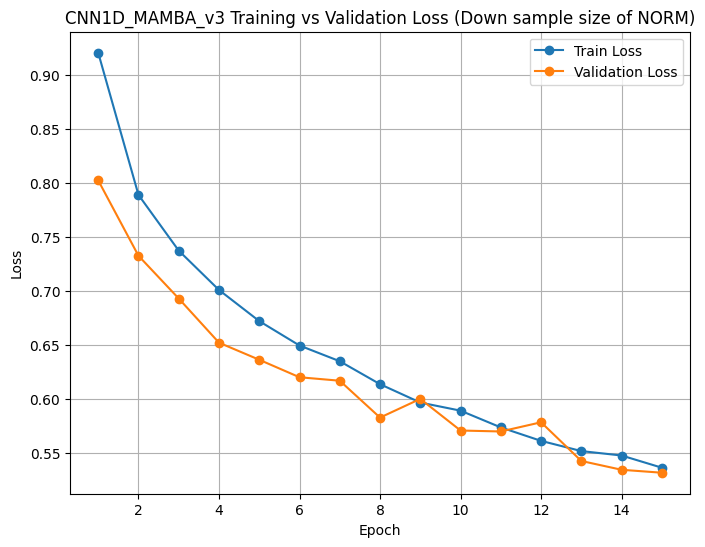

In [49]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,6))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN1D_MAMBA_v3 Training vs Validation Loss (Down sample size of NORM)')
plt.legend()
plt.grid(True)
plt.show()

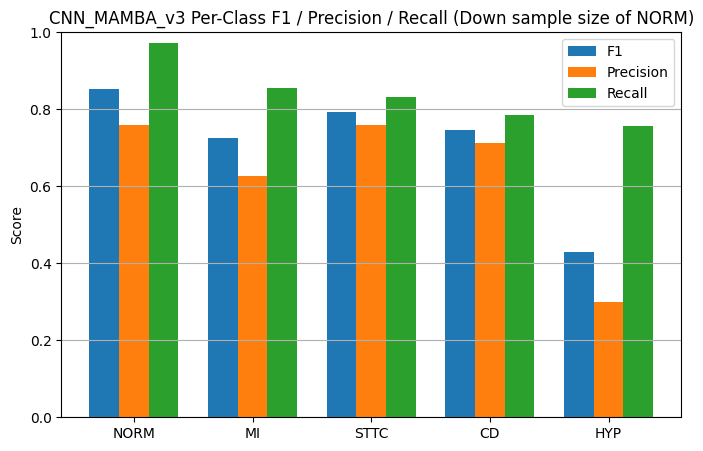

In [50]:
# Take last epoch metrics
metrics = val_metrics_history[-1]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, metrics['f1_per_class'], width, label='F1')
plt.bar(x, metrics['precision_per_class'], width, label='Precision')
plt.bar(x + width, metrics['recall_per_class'], width, label='Recall')
plt.xticks(x, classes)
plt.ylabel('Score')
plt.ylim(0,1)
plt.title('CNN_MAMBA_v3 Per-Class F1 / Precision / Recall (Down sample size of NORM)')
plt.legend()
plt.grid(axis='y')
plt.show()

In [51]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_roc_curves(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.permute(0,2,1).to(device)
            yb = yb.to(device)

            outputs = torch.sigmoid(model(xb))

            all_preds.append(outputs.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    n_classes = all_labels.shape[1]

    fpr_dict = {}
    tpr_dict = {}
    auc_dict = {}

    plt.figure(figsize=(8,6))

    # ----- Compute ROC for each class -----
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
        roc_auc = auc(fpr, tpr)

        fpr_dict[i] = fpr
        tpr_dict[i] = tpr
        auc_dict[i] = roc_auc

        plt.plot(
            fpr,
            tpr,
            label=f"{class_names[i]} (AUROC = {roc_auc:.3f})"
        )

    # ----- Compute Macro ROC -----
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

    mean_tpr /= n_classes

    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr,
        mean_tpr,
        linestyle="--",
        linewidth=3,
        label=f"Macro-average (AUROC = {macro_auc:.3f})"
    )

    # Random baseline
    plt.plot([0,1],[0,1],'k--', label="Random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves for 5 ECG Classes")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show()

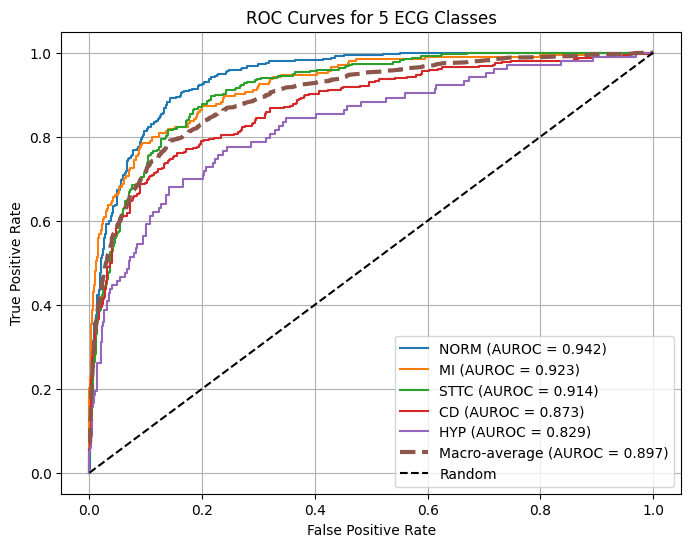

In [81]:
class_names = ["NORM", "MI", "STTC", "CD", "HYP"]

plot_roc_curves(model_mamba, test_loader, device, class_names)

# Findings

## Jay's Findings

In this project, I trained and evaluated two deep‑learning architectures on the PTB‑XL ECG dataset: a Baseline 1D CNN and a Transfer‑ResNet‑1D model. The goal was to understand how architectural complexity affects ECG classification performance.

Learning Behavior (Training & Validation Loss) Both models showed steadily decreasing training loss, confirming that they successfully learned ECG patterns. However, the ResNet‑1D model had a smoother and more stable validation loss curve, indicating better generalization and less overfitting. The Baseline CNN learned quickly but showed mild divergence between training and validation loss, suggesting it was more sensitive to noise and class imbalance.

Macro F1 Score (Performance Across All Classes) Macro F1 treats all diagnostic classes equally, including minority classes like HYP and CD.

The Baseline CNN performed reasonably well but struggled with smaller classes.

The ResNet‑1D model achieved a higher Macro F1, showing it was better at detecting less common heart conditions. This improvement comes from ResNet’s deeper feature extraction and residual connections.

Micro F1 Score (Performance on Common Classes) Micro F1 is influenced by large classes such as “Normal.”
Both models performed similarly, meaning they both classify common conditions effectively.

The ResNet‑1D model had a slight advantage, indicating improved handling of class imbalance.

Overall Interpretation The findings show that:
The Baseline 1D CNN is simple, fast, and effective for general ECG classification.

The ResNet‑1D model provides better stability, deeper feature learning, and improved performance, especially on minority classes.

The training curves and F1 comparisons demonstrate that adding residual connections leads to more balanced and reliable predictions.

Conclusion While the baseline CNN provides a strong foundation, the ResNet‑1D architecture delivers meaningful performance gains and better generalization. This highlights the importance of architectural design when working with complex biomedical signals like ECGs.

## Joisah' Findings

A 1-dimensional Convolutional Neural Network (CNN) was developed using PyTorch to classify electrocardiogram (ECG) signals into five diagnostic categories using the PTB-XL. The cleaned dataset contained about 14,367 ECG recordings sampled at 100 Hz. These were split into training (11,528 samples), validation (1,415 samples), and test (1,424 samples) sets using the dataset’s predefined folds. The model consisted of four convolutional blocks that extract important waveform patterns from the ECG signals. Each block included convolution, batch normalization, ReLU activation, and max pooling layers. After feature extraction, global average pooling and fully connected layers were used to produce the final predictions for the five classes. The model was trained using binary cross-entropy with logits loss and the Adam optimizer.

During training, the model showed steady improvement. The training loss gradually decreased over the epochs, indicating that the model was learning the patterns in the ECG signals. The validation loss fluctuated slightly and began to increase after around epoch 10, suggesting mild overfitting. However, the validation Macro AUROC remained stable around 0.91–0.92, which indicates strong overall classification performance.

The model achieved a peak validation Macro AUROC of approximately 0.92, demonstrating that the CNN was able to effectively distinguish between the ECG diagnostic classes. The Macro F1 score ranged between 0.65 and 0.70, which is expected for multilabel medical datasets with class imbalance. When examining individual classes, the NORM and MI (Myocardial Infarction) categories achieved the highest AUROC values, around 0.95, indicating that these conditions were easier for the model to detect. The STTC and CD classes also showed strong performance with AUROC values around 0.92–0.93. The HYP (Hypertrophy) class had lower AUROC values, typically between 0.83 and 0.87, suggesting that hypertrophy patterns are more difficult for the model to identify. This behavior is consistent with findings reported in other ECG classification studies.

Overall, the CNN model performed well for ECG classification using the 100 Hz PTB-XL data. The model successfully learned meaningful ECG features and showed good generalization on validation data. The best performance occurred around epochs 10–14, indicating that training beyond this point may lead to overfitting. These results show that a relatively simple CNN can achieve strong baseline performance for automated ECG diagnosis.

## Kam's Findings

To improve ECG classification performance, a hybrid CNN + Mamba architecture was developed to combine the strengths of convolutional feature extraction and sequence modeling. The convolutional neural network (CNN) layers were first used to extract local temporal features from the multi-lead ECG signals, while the Mamba layer was introduced to model long-range dependencies across the ECG sequence. This design allows the model to capture both short-term waveform patterns and longer temporal relationships within the signal.

During model development, several configurations were tested to optimize the architecture, including adjustments to the number of CNN layers and the integration position of the Mamba block. A four-layer CNN structure followed by a Mamba module provided the most stable training performance. The model was trained using the PTB-XL dataset with appropriate preprocessing and class imbalance handling strategies.

The final CNN + Mamba model achieved a macro accuracy of 0.8346, macro F1-score of 0.6772, and macro AUROC of 0.8961, demonstrating strong overall classification capability. Importantly, the model achieved an F1-score of 0.4126 and AUROC of 0.8285 for the HYP class, which represents a minority abnormal condition in the dataset. These results indicate that the hybrid architecture can effectively detect minority pathological patterns while maintaining competitive overall performance. The findings suggest that integrating sequence modeling through Mamba improves the model’s ability to capture complex temporal characteristics in ECG signals.

# Models Comparsion

In [71]:
import pandas as pd

def create_results_table(metrics, model_name):

    # HYP index (based on PTB-XL superclass order)
    HYP_INDEX = 4

    data = {
        "Model": [model_name],
        "Macro Accuracy": [acc],
        "Macro F1": [metrics["macro_f1"]],
        "Macro Precision": [metrics["macro_precision"]],
        "Macro Recall": [metrics["macro_recall"]],
        "Macro AUROC" : [metrics["macro_auroc"]],
        "HYP F1": [metrics["f1_per_class"][HYP_INDEX]],
        "HYP AUROC": [metrics["auroc_per_class"][HYP_INDEX]]
    }

    df = pd.DataFrame(data)

    return df

In [72]:

def insert_baseline_row(results_df, history, metrics, model_name="Baseline CNN"):

    HYP_INDEX = 4  # PTB-XL superclass order

    new_row = {
        "Model": model_name,
        "Macro F1": history["macro_f1"][-1],
        "Macro Precision": metrics["macro_precision"],
        "Macro Recall": metrics["macro_recall"],
        "Macro AUROC" :val_metrics['macro_auroc'],
        "HYP F1": metrics["f1_per_class"][HYP_INDEX],
        "HYP AUROC": history["per_class_auroc"][-1][HYP_INDEX]
    }

    new_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

    return new_df

In [73]:
metrics_mamba = compute_per_class_metrics(model_mamba, test_loader, device)

results_table = create_results_table(metrics_mamba, "CNN + MAMBA")

results_table

,Model,Macro Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUROC,HYP F1,HYP AUROC
0,CNN + MAMBA,0.834575,0.67715,0.606535,0.79375,0.896074,0.412607,0.828544


In [76]:
metrics_cnn = compute_per_class_metrics_cnn(model, test_cnn_loader, device)

results_table = insert_baseline_row(
    results_table,
    history,
    metrics_cnn,
    "Baseline CNN"
)

results_table

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

,Model,Macro Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUROC,HYP F1,HYP AUROC
0,CNN + MAMBA,0.834575,0.677150,0.606535,0.79375,0.896074,0.412607,0.828544
1,Baseline CNN,NaN,0.755425,0.038968,0.20000,0.955611,0.000000,0.911999


In [77]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

def extract_metrics(model_name, results, y_test, y_pred_prob, class_names):
    df = results[model_name]

    # Macro metrics
    macro_accuracy = df.loc["accuracy", "precision"] if "accuracy" in df.index else np.nan
    macro_f1 = df.loc["macro avg", "f1-score"]
    macro_precision = df.loc["macro avg", "precision"]
    macro_recall = df.loc["macro avg", "recall"]

    # AUROC (macro)
    macro_auroc = roc_auc_score(y_test, y_pred_prob, average="macro")

    # HYP metrics
    hyp_index = class_names.index("HYP")
    hyp_f1 = df.loc["HYP", "f1-score"]
    hyp_auroc = roc_auc_score(y_test[:, hyp_index], y_pred_prob[:, hyp_index])

    return {
        "Model": model_name,
        "Macro Accuracy": macro_accuracy,
        "Macro F1": macro_f1,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro AUROC": macro_auroc,
        "HYP F1": hyp_f1,
        "HYP AUROC": hyp_auroc
    }

# Build table for all models
rows = []

for model_name, model in models.items():
    y_pred_prob = model.predict(X_test)
    metrics = extract_metrics(model_name, results, y_test, y_pred_prob, class_names)
    rows.append(metrics)

final_table = pd.DataFrame(rows)
final_table


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


,Model,Macro Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUROC,HYP F1,HYP AUROC
0,Baseline 1D CNN,NaN,0.603541,0.861755,0.539199,0.894132,0.127273,0.818825
1,ResNet-1D,NaN,0.655893,0.782908,0.592963,0.899495,0.419580,0.837214
2,Dilated Multi-Scale CNN,NaN,0.664605,0.792022,0.624649,0.907761,0.272000,0.845061


In [78]:
results_table = pd.concat([results_table, final_table], ignore_index=True)

results_table

,Model,Macro Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUROC,HYP F1,HYP AUROC
0,CNN + MAMBA,0.834575,0.677150,0.606535,0.793750,0.896074,0.412607,0.828544
1,Baseline CNN,NaN,0.755425,0.038968,0.200000,0.955611,0.000000,0.911999
2,Baseline 1D CNN,NaN,0.603541,0.861755,0.539199,0.894132,0.127273,0.818825
3,ResNet-1D,NaN,0.655893,0.782908,0.592963,0.899495,0.419580,0.837214
4,Dilated Multi-Scale CNN,NaN,0.664605,0.792022,0.624649,0.907761,0.272000,0.845061


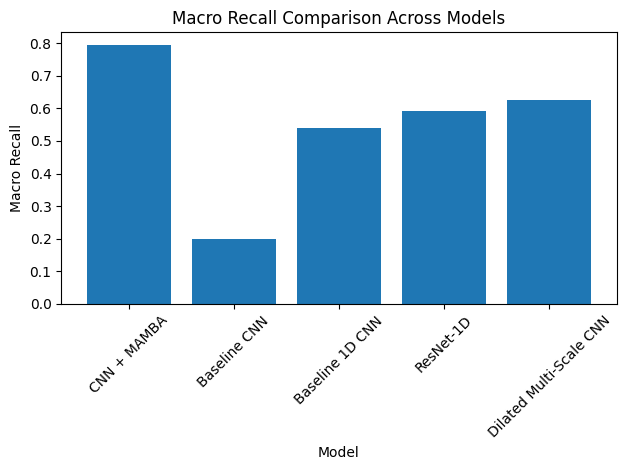

In [79]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(results_table["Model"], results_table["Macro Recall"])

plt.xlabel("Model")
plt.ylabel("Macro Recall")
plt.title("Macro Recall Comparison Across Models")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

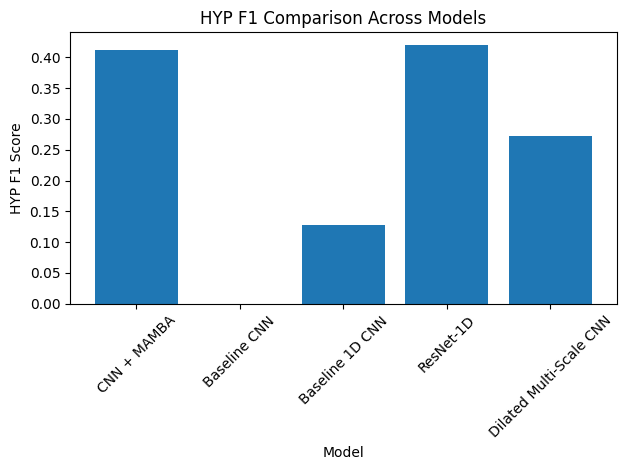

In [80]:
plt.figure()

plt.bar(results_table["Model"], results_table["HYP F1"])

plt.xlabel("Model")
plt.ylabel("HYP F1 Score")
plt.title("HYP F1 Comparison Across Models")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Conculsion

During the model development process, multiple architectures were evaluated, including a baseline CNN model, a ResNet model, and the proposed CNN + Mamba model. Although the baseline CNN and ResNet models achieved slightly higher macro performance metrics in some areas, the project prioritizes detecting abnormal cardiac conditions rather than maximizing overall accuracy. Since the PTB-XL dataset is highly imbalanced and dominated by the NORM class, macro metrics can be influenced by the majority class and may not fully reflect the model’s ability to detect minority pathological conditions.

For a pre-diagnosis screening system, minimizing false negatives is critical because missing abnormal cases could delay medical attention. Therefore, the evaluation focused on the model's performance on minority classes, particularly the HYP class. The CNN + Mamba model achieved the highest F1-score for HYP, indicating a better balance between precision and recall for detecting this abnormal condition. While the ResNet model showed a slightly higher AUROC for HYP, the CNN + Mamba model provided stronger classification performance at the decision threshold.

Based on these results, the CNN + Mamba model was selected as the final model for deployment in the pre-diagnosis system. This model provides improved detection of minority pathological cases while maintaining competitive overall performance, making it more suitable for assisting cardiologists in identifying potentially abnormal ECG signals for further review.

# References

Śmigiel, S., Pałczyński, K., & Ledziński, D. (2021). ECG signal classification using deep learning techniques based on the PTB-XL dataset. Entropy, 23(9), 1121. https://doi.org/10.3390/e23091121

Wagner, P., Strodthoff, N., Bousseljot, R., Samek, W., & Schaeffter, T. (2020). PTB-XL, a large publicly available electrocardiography dataset. Scientific Data, 7, 154. https://doi.org/10.1038/s41597-020-0495-6